# Common Text Cleaning - Vietnamese Fact Checking

Notebook này thực hiện bước tiền xử lý chung cho dataset ViFactCheck.

Mục tiêu:
- Loại bỏ nhiễu kỹ thuật trong dữ liệu.
- Chuẩn hóa dữ liệu tiếng Việt.
- Bảo toàn thông tin ngữ nghĩa phục vụ bài toán Fact Checking.

Các bước đặc thù của từng mô hình như tokenization, word segmentation,
lowercase, stopword removal hoặc tạo embedding sẽ được thực hiện ở pipeline riêng.

## Nguyên tắc

Common cleaning sẽ làm:

1. Xử lý missing values cho `claim`, `evidence`, `label`.
2. Xóa HTML tags và unescape HTML entities.
3. Chuẩn hóa Unicode về NFC.
4. Giữ nguyên URL gốc để không mất tín hiệu nguồn cho LLM.
5. Xóa ký tự lỗi/không in được.
6. Xóa emoji và symbol noise không cần thiết.
7. Chuẩn hóa khoảng trắng.

### Why not: Không replace URL ở common cleaning

Vì project có dùng LLM fine-tuning, URL gốc có thể chứa tín hiệu quan trọng như domain nguồn, chuyên mục, ngày tháng hoặc slug bài viết. Các model truyền thống như TF-IDF/FastText có thể replace URL trong pipeline riêng nếu cần.

### Why not: Không lowercase

Vì PhoBERT và LLM tokenizer có cơ chế xử lý riêng, đồng thời viết hoa có thể chứa thông tin về thực thể. Ví dụ `WHO`, `Bộ Y tế`, `TP.HCM` có thể là tín hiệu hữu ích cho fact checking.

### Why not: Không tokenize / word segmentation

Vì mỗi hướng model cần một cách biểu diễn khác nhau: TF-IDF và FastText thường cần word segmentation, PhoBERT có quy ước tokenizer riêng, còn LLM cần prompt formatting và tokenizer của model.

### Why not: Không remove stopword

Vì các từ phủ định như `không`, `chưa`, `chẳng` ảnh hưởng trực tiếp đến tính đúng/sai. Xóa stopword ở common step có thể làm đổi nghĩa claim hoặc evidence.


In [1]:
# Import các thư viện cần cho common cleaning.
# Path dùng để quản lý đường dẫn dữ liệu.
# html, re, unicodedata dùng để xử lý HTML, URL, Unicode và ký tự lỗi.
# pandas dùng để đọc/ghi CSV và thống kê dữ liệu.

from pathlib import Path
import html
import re
import unicodedata

import pandas as pd

# Hiển thị text dài hơn khi xem mẫu dữ liệu trong notebook.
pd.set_option("display.max_colwidth", 180)

# Xác định thư mục gốc của project để notebook chạy được từ root hoặc từ notebooks/preprocessing.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "preprocessing":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]

# Khai báo thư mục dữ liệu raw, output sau common cleaning và report audit.
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "ViFactCheck_original"
OUT_DIR = PROJECT_ROOT / "data" / "processed" / "common_cleaned"
REPORT_DIR = PROJECT_ROOT / "reports" / "common_cleaning"

# Mapping tên split với file CSV tương ứng.
SPLIT_FILES = {
    "train": RAW_DIR / "vifactcheck_train.csv",
    "dev": RAW_DIR / "vifactcheck_dev.csv",
    "test": RAW_DIR / "vifactcheck_test.csv",
}

# Kiểm tra sớm để tránh chạy pipeline khi thiếu file dữ liệu.
for split, path in SPLIT_FILES.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing {split} file: {path}")

# Tạo thư mục output/report nếu chưa tồn tại.
OUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR, REPORT_DIR


(PosixPath('/Users/mivu/Documents/Artificial Intelligence/CS221-NLP/Project-NLP-Fact-Checking/data/processed/common_cleaned'),
 PosixPath('/Users/mivu/Documents/Artificial Intelligence/CS221-NLP/Project-NLP-Fact-Checking/reports/common_cleaning'))

In [2]:
# Khảo sát dữ liệu gốc trước khi tiền xử lý.
# Bước này giúp kiểm tra cấu trúc dataset, tên cột và một số mẫu dữ liệu đầu vào.
train_preview = pd.read_csv(SPLIT_FILES["train"], nrows=5)
train_preview.info()
train_preview.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     5 non-null      int64 
 1   index          5 non-null      int64 
 2   Statement      5 non-null      object
 3   Context        5 non-null      object
 4   annotation_id  5 non-null      int64 
 5   Topic          5 non-null      object
 6   Author         5 non-null      object
 7   Url            5 non-null      object
 8   labels         5 non-null      int64 
 9   Evidence       5 non-null      object
dtypes: int64(4), object(6)
memory usage: 532.0+ bytes


,Unnamed: 0,index,Statement,Context,annotation_id,Topic,Author,Url,labels,Evidence
0,0,3049,"Phó Thủ tướng Trần Hồng Hà thay mặt Chính phủ, Thủ tướng Chính phủ chúc mừng Đài Truyền hình Việt Nam, Đài truyền hình các tỉnh, thành phố trên cả nước, các đơn vị sản xuất tru...","(Chinhphu.vn) - Đây là mong muốn, gửi gắm của Phó Thủ tướng Trần Hồng Hà đến những người làm truyền hình tại lễ bế mạc Liên hoan Truyền hình toàn quốc lần thứ 41, tối 18/3, tại...",18933775,Chính trị,Chính Phủ,https://baochinhphu.vn/lan-toa-nhung-gia-tri-van-hoa-tot-dep-chan-thien-my-cua-dan-toc-102230318225051612.htm,0,"Thay mặt Chính phủ, Thủ tướng Chính phủ, Phó Thủ tướng Trần Hồng Hà chúc mừng Đài Truyền hình Việt Nam, Đài truyền hình các tỉnh, thành phố trên cả nước, các đơn vị sản xuất tr..."
1,1,6811,"Hành vi của Tô Văn Hải là cho phép người khác đổ chất thải rắn ra môi trường vàchôn, lấp chất thải trái phép.","Ngày 24/3, Cơ quan Cảnh sát điều tra Công an tỉnh Bình Dương cho biết, đơn vị vừa thực hiện lệnh bắt bị can để tạm giam đối với Tô Văn Hải (sinh năm 1970, hộ khẩu thường trú xã...",19402113,PHÁP LUẬT,Tin Tức,https://baotintuc.vn/an-ninh-trat-tu/bat-tam-giam-doi-tuong-chon-lap-hon-600-tan-chat-thai-ra-moi-truong-20230324173816078.htm,0,"Tô Văn Hải đã có hành vi cho phép người khác đổ, thải chất thải rắn thông thường ra môi trường Giáo). Sau đó, Hải tiến hành chôn, lấp tổng khối lượng 642.070 kg chất thải mà kh..."
2,2,7270,"SAWACO thông báo tạm ngưng cung cấp nước để thực hiện công tác bảo trì, bảo dưỡng định kỳ Nhà máy nước Tân Hiệp, thời gian thực hiện dự kiến từ 12 giờ ngày 25-3 (thứ bảy) đến 4...","(PLO)- Theo Tổng Công ty Cấp nước Sài Gòn (SAWACO) việc cúp nước là để thực hiện công tác bảo trì, bảo dưỡng định kỳ Nhà máy nước Tân Hiệp. SAWACO cho biết đây là phương án để ...",19807472,ĐÔ THỊ,Báo Pháp Luật HCM,https://plo.vn/9-quan-huyen-o-tphcm-se-bi-cup-nuoc-vao-cuoi-tuan-nay-post725015.html,1,SAWACO thông báo tạm ngưng cung cấp nước để thực hiện công tác nêu trên. Thời gian thực hiện dự kiến từ 22 giờ ngày 25-3 (thứ bảy) đến 4 giờ ngày 26-3 (chủ nhật).
3,3,7423,"CLB luôn chuẩn bị rất kỹ lưỡng, chỉn chu chương trình lớn nhất trong năm, tuy nhiên vẫn gặp không ít thử thách chẳng hạn như NABC mùa 4 còn 10 ngày nữa là diễn ra nhưng quỹ ngu...","Với khoảng 200 thành viên, UEF Warm Hugs Club - một câu lạc bộ thiện nguyện thuộc Trường Đại học Kinh tế - Tài chính TP HCM (UEF) - đang ngày càng tạo được dấu ấn tích cực tron...",19725173,Giáo dục,Người lao động,https://nld.com.vn/giao-duc-khoa-hoc/hanh-trinh-cua-nhung-chiec-om-20230325201419584.htm,2,"Là chương trình lớn nhất của CLB trong năm nên mọi thứ được chuẩn bị rất kỹ lưỡng, chỉn chu và cũng không ít lần gặp thử thách NABC mùa 4 gây quỹ không đủ khi chỉ còn cách ngày..."
4,4,6632,"ILA tiếp nhận và hỗ trợ học sinh miễn phí, Bé được tham gia kiểm tra trình độ đầu vào, điểm đầu vào từ 20 điểm được học, tư vấn xếp lớp rất nhanh chóng và nhiệt tình.","Đi qua 2 năm dịch bệnh đầy thử thách, nhưng chỉ trong 3 tháng đầu năm 2023, tổ chức giáo dục ILA đã liên tục mở rộng thêm chi nhánh, trong đó mới nhất là Trung tâm ILA Đảo Kim ...",19021291,Giáo dục,Thanh Niên,https://thanhnien.vn/giao-duc-anh-ngu-phat-trien-manh-me-bat-chap-khung-hoang-hau-covid-19-185230320124322595.htm,2,"Bé được tham gia kiểm tra trình độ đầu vào, tư vấn xếp lớp rất nhanh chóng và nhiệt tình ILA tiếp nhận và hỗ trợ học sinh miễn phí"


## Mapping cột trong ViFactCheck

Dataset gốc dùng tên cột:

- `Statement`: claim cần kiểm chứng.
- `Context`: văn bản bài viết/ngữ cảnh nguồn.
- `Evidence`: đoạn bằng chứng liên quan trực tiếp.
- `labels`: nhãn.
- `Url`: URL nguồn.

Pipeline này giữ nguyên các cột metadata, đồng thời tạo thêm các cột cleaned để các pipeline model-specific dùng tiếp.

In [3]:
# Các cột text sẽ được áp dụng common cleaning.
TEXT_COLUMNS = ["Statement", "Context", "Evidence"]

# Các cột bắt buộc để một dòng có thể dùng cho huấn luyện/evaluation.
REQUIRED_COLUMNS = ["Statement", "Evidence", "labels"]

# Tạo cột cleaned mới thay vì ghi đè cột gốc để dễ audit và so sánh before/after.
CLEAN_COLUMN_NAMES = {
    "Statement": "claim_clean",
    "Context": "context_clean",
    "Evidence": "evidence_clean",
}

# Regex nhận diện URL thô trong claim/evidence/context để thống kê, không replace ở common cleaning.
URL_PATTERN = re.compile(r"(?i)\b(?:https?://|www\.)\S+|\b\S+\.(?:com|vn|net|org|edu|gov)\S*")

# Regex xử lý HTML tag và khoảng trắng thừa.
HTML_TAG_PATTERN = re.compile(r"<[^>]+>")
WHITESPACE_PATTERN = re.compile(r"\s+")

# Regex nhận diện emoji/symbol noise.
# Không xóa các dấu câu quan trọng như ?, !, %, -, / vì chúng có thể mang nghĩa trong fact checking.
EMOJI_PATTERN = re.compile(
    "["
    "\U0001F1E6-\U0001F1FF"
    "\U0001F300-\U0001F5FF"
    "\U0001F600-\U0001F64F"
    "\U0001F680-\U0001F6FF"
    "\U0001F700-\U0001F77F"
    "\U0001F780-\U0001F7FF"
    "\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FA6F"
    "\U0001FA70-\U0001FAFF"
    "\u2600-\u26FF"
    "\u2700-\u27BF"
    "]+"
)

def remove_corrupted_chars(text: str) -> str:
    """Xóa ký tự replacement/control thường xuất hiện do lỗi encoding/decoding."""
    chars = []
    for char in text:
        category = unicodedata.category(char)

        # Ký tự � thường cho biết text bị decode lỗi.
        if char == "\ufffd":
            continue

        # Xóa control characters, nhưng giữ tab/newline để bước normalize whitespace xử lý sau.
        if category.startswith("C") and char not in {"\t", "\n", "\r"}:
            continue

        chars.append(char)
    return "".join(chars)

def clean_common_text(value) -> str:
    """Làm sạch text ở mức common, không thay đổi biểu diễn riêng của từng model."""
    # Missing text được chuyển thành chuỗi rỗng; dòng rỗng sẽ bị lọc ở clean_split.
    if pd.isna(value):
        return ""

    text = str(value)

    # Chuyển HTML entity như &amp; về ký tự thật.
    text = html.unescape(text)

    # Xóa HTML tag crawl từ web.
    text = HTML_TAG_PATTERN.sub(" ", text)

    # Chuẩn hóa Unicode NFC để tránh cùng một tiếng Việt nhưng có nhiều dạng mã hóa.
    text = unicodedata.normalize("NFC", text)

    # Giữ nguyên URL gốc để LLM có thể học tín hiệu domain/path/slug nếu cần.

    # Xóa ký tự lỗi và emoji/symbol noise.
    text = remove_corrupted_chars(text)
    text = EMOJI_PATTERN.sub(" ", text)

    # Gom nhiều khoảng trắng thành một khoảng trắng duy nhất.
    text = WHITESPACE_PATTERN.sub(" ", text).strip()
    return text

def detect_clean_reason(raw, clean):
    """Gán nhãn lý do một cell bị thay đổi để phục vụ audit."""
    reasons = []

    raw = "" if pd.isna(raw) else str(raw)
    clean = "" if pd.isna(clean) else str(clean)

    # HTML tag bị xóa, ví dụ <p>...</p>.
    if HTML_TAG_PATTERN.search(raw):
        reasons.append("HTML removal")

    # HTML entity được giải mã, ví dụ &amp; -> &.
    if html.unescape(raw) != raw:
        reasons.append("HTML entity unescape")

    # Unicode NFC gộp các dấu tiếng Việt về cùng một biểu diễn.
    if raw != unicodedata.normalize("NFC", raw):
        reasons.append("Unicode normalization")

    # Ký tự � xuất hiện khi text bị decode lỗi.
    if "�" in raw:
        reasons.append("Corrupted character removal")

    # Emoji/symbol noise bị xóa khỏi text.
    if EMOJI_PATTERN.search(raw):
        reasons.append("Emoji removal")

    # Control character không hiển thị như backspace \x08 bị xóa.
    has_control_char = any(
        unicodedata.category(char) == "Cc" and char not in {"\t", "\n", "\r"}
        for char in raw
    )
    if has_control_char:
        reasons.append("Control character removal")

    # Format/zero-width character như ZERO WIDTH NON-JOINER \u200c bị xóa.
    has_format_char = any(unicodedata.category(char) == "Cf" for char in raw)
    if has_format_char:
        reasons.append("Zero-width/format character removal")

    # Khoảng trắng dư, tab/newline được gom về một khoảng trắng.
    if WHITESPACE_PATTERN.sub(" ", raw).strip() != raw:
        reasons.append("Whitespace normalization")

    # Nếu còn trường hợp chưa gắn nhãn, hiển thị rõ cần bổ sung rule thay vì ghi Other.
    return ", ".join(reasons) if reasons else "Needs explicit reason rule"

def clean_split(df: pd.DataFrame, keep_audit: bool = False) -> pd.DataFrame:
    """Clean một split và lưu thống kê audit trong DataFrame attrs."""
    # Đảm bảo dataset có đủ cột cần thiết trước khi xử lý.
    missing_columns = [
        col for col in REQUIRED_COLUMNS + TEXT_COLUMNS
        if col not in df.columns
    ]
    if missing_columns:
        raise ValueError(f"Missing columns: {missing_columns}")

    cleaned = df.copy()
    before_rows = len(cleaned)

    # Giữ lại index gốc để đếm đúng số dòng bị thay đổi, kể cả khi nhiều cột cùng thay đổi.
    cleaned["_source_row_id"] = cleaned.index

    # Loại các dòng thiếu claim/evidence/label vì không đủ input hoặc target cho model.
    for col in REQUIRED_COLUMNS:
        cleaned = cleaned[cleaned[col].notna()]

    audit_rows = []
    changed_row_ids = set()
    changed_counts_by_column = {}

    for raw_col, clean_col in CLEAN_COLUMN_NAMES.items():
        # Lưu text sau cleaning vào cột mới, không ghi đè text gốc.
        cleaned[clean_col] = cleaned[raw_col].map(clean_common_text)

        # Một cell được tính là changed nếu raw text khác cleaned text.
        raw_text = cleaned[raw_col].fillna("").astype(str)
        clean_text = cleaned[clean_col].fillna("").astype(str)
        changed_mask = raw_text.ne(clean_text)
        changed_counts_by_column[raw_col] = int(changed_mask.sum())
        changed_row_ids.update(cleaned.loc[changed_mask, "_source_row_id"].tolist())

        if keep_audit:
            # Lưu chi tiết các cell bị thay đổi theo schema thống nhất để dễ đọc.
            changed_df = cleaned.loc[changed_mask, ["_source_row_id", raw_col, clean_col]].copy()
            changed_df = changed_df.rename(
                columns={
                    "_source_row_id": "source_row_id",
                    raw_col: "raw_text",
                    clean_col: "clean_text",
                }
            )
            changed_df["column"] = raw_col
            changed_df["reason"] = changed_df.apply(
                lambda row: detect_clean_reason(row["raw_text"], row["clean_text"]),
                axis=1,
            )
            changed_df = changed_df[["source_row_id", "column", "raw_text", "clean_text", "reason"]]
            audit_rows.append(changed_df)

    # Chuẩn hóa tên label để các pipeline sau dùng nhất quán.
    cleaned["label_clean"] = cleaned["labels"]

    # Sau cleaning, loại các dòng có claim/evidence rỗng.
    non_empty_mask = (
        cleaned["claim_clean"].str.len().gt(0)
        & cleaned["evidence_clean"].str.len().gt(0)
        & cleaned["label_clean"].notna()
    )
    cleaned = cleaned[non_empty_mask].reset_index(drop=True)

    # Lưu các thống kê audit vào attrs để summary cell lấy ra.
    retained_row_ids = set(cleaned["_source_row_id"].tolist())
    cleaned.attrs["dropped_rows"] = before_rows - len(cleaned)
    cleaned.attrs["changed_rows"] = len(changed_row_ids & retained_row_ids)
    cleaned.attrs["changed_counts_by_column"] = changed_counts_by_column
    cleaned.attrs["audit"] = pd.concat(audit_rows, ignore_index=True) if keep_audit and audit_rows else pd.DataFrame()

    # Không ghi cột kỹ thuật ra output cleaned.
    cleaned = cleaned.drop(columns=["_source_row_id"])
    return cleaned


## Kiểm tra nhanh từng bước cleaning

In [4]:
# Ví dụ nhỏ để kiểm tra từng loại nhiễu kỹ thuật được xử lý như kỳ vọng.
# Lưu ý: URL được giữ nguyên ở common cleaning vì project có dùng LLM.

examples = pd.Series([
    "<p>WHO công bố thông tin</p>",
    "Co\u0302ng nghe\u0323\u0302 Việt Nam    công bố     thông tin",
    "Nguồn: https://abc.com/news?id=123 và www.example.vn/bai-viet",
    "Tin này quá sốc!!! 😱😱😱 COVID-19 tăng 95% ngày 12/5/2024",
    "Chính ph\ufffd\ufffd\ufffd công bố",
])

pd.DataFrame({"raw": examples, "cleaned": examples.map(clean_common_text)})


,raw,cleaned
0,<p>WHO công bố thông tin</p>,WHO công bố thông tin
1,Công nghệ Việt Nam công bố thông tin,Công nghệ Việt Nam công bố thông tin
2,Nguồn: https://abc.com/news?id=123 và www.example.vn/bai-viet,Nguồn: https://abc.com/news?id=123 và www.example.vn/bai-viet
3,Tin này quá sốc!!! 😱😱😱 COVID-19 tăng 95% ngày 12/5/2024,Tin này quá sốc!!! COVID-19 tăng 95% ngày 12/5/2024
4,Chính ph��� công bố,Chính ph công bố


In [5]:
# Chạy common cleaning cho từng split dữ liệu.
# keep_audit=True giúp đếm số row/cell thực sự bị thay đổi sau cleaning.

raw_splits = {}
cleaned_splits = {}
summary_rows = []

for split, path in SPLIT_FILES.items():
    # Đọc dữ liệu gốc của split hiện tại.
    raw_df = pd.read_csv(path)

    # Làm sạch dữ liệu và bật audit để biết cleaning đã tác động bao nhiêu dòng.
    cleaned_df = clean_split(raw_df, keep_audit=True)

    raw_splits[split] = raw_df
    cleaned_splits[split] = cleaned_df

    # Ghi file cleaned để các pipeline model-specific dùng lại.
    # File output dùng lại tên cột gốc: Statement/Context/Evidence/labels.
    # Các cột *_clean chỉ dùng nội bộ trong notebook để audit, không xuất ra file cuối.
    output_df = cleaned_df.copy()
    output_df["Statement"] = output_df["claim_clean"]
    output_df["Context"] = output_df["context_clean"]
    output_df["Evidence"] = output_df["evidence_clean"]
    output_df["labels"] = output_df["label_clean"]
    output_df = output_df.drop(
        columns=["claim_clean", "context_clean", "evidence_clean", "label_clean"]
    )

    output_path = OUT_DIR / f"vifactcheck_{split}_common_cleaned.csv"
    output_df.to_csv(output_path, index=False)

    changed_counts = cleaned_df.attrs["changed_counts_by_column"]

    # changed_rows = số dòng có ít nhất một cột text bị thay đổi sau common cleaning.
    summary_rows.append({
        "split": split,
        "raw_rows": len(raw_df),
        "cleaned_rows": len(cleaned_df),
        "dropped_rows": cleaned_df.attrs["dropped_rows"],
        "changed_rows": cleaned_df.attrs["changed_rows"],
        "changed_claim_rows": changed_counts["Statement"],
        "changed_context_rows": changed_counts["Context"],
        "changed_evidence_rows": changed_counts["Evidence"],
        "output_path": str(output_path.relative_to(PROJECT_ROOT)),
    })

summary = pd.DataFrame(summary_rows)
summary


,split,raw_rows,cleaned_rows,dropped_rows,changed_rows,changed_claim_rows,changed_context_rows,changed_evidence_rows,output_path
0,train,5062,5062,0,696,412,345,83,data/processed/common_cleaned/vifactcheck_train_common_cleaned.csv
1,dev,723,723,0,79,45,38,10,data/processed/common_cleaned/vifactcheck_dev_common_cleaned.csv
2,test,1447,1447,0,191,117,90,19,data/processed/common_cleaned/vifactcheck_test_common_cleaned.csv


In [6]:
# Xem chi tiết một số cell thực sự bị thay đổi bởi common cleaning.
# Bảng này giúp kiểm tra cleaning có đang xử lý đúng loại nhiễu kỳ vọng không.

audit_examples = cleaned_splits["train"].attrs["audit"]
audit_examples.head(10)


,source_row_id,column,raw_text,clean_text,reason
0,0,Statement,"Phó Thủ tướng Trần Hồng Hà thay mặt Chính phủ, Thủ tướng Chính phủ chúc mừng Đài Truyền hình Việt Nam, Đài truyền hình các tỉnh, thành phố trên cả nước, các đơn vị sản xuất tru...","Phó Thủ tướng Trần Hồng Hà thay mặt Chính phủ, Thủ tướng Chính phủ chúc mừng Đài Truyền hình Việt Nam, Đài truyền hình các tỉnh, thành phố trên cả nước, các đơn vị sản xuất tru...",Whitespace normalization
1,11,Statement,"Dự báo nhu cầu điện sẽ tiếp tục tăng trong giai đoạn tới, lên cao nhất 27,3% vào năm 2025 và đến năm 2024 tăng lên khoảng 26%.\n","Dự báo nhu cầu điện sẽ tiếp tục tăng trong giai đoạn tới, lên cao nhất 27,3% vào năm 2025 và đến năm 2024 tăng lên khoảng 26%.",Whitespace normalization
2,32,Statement,Loại cà phê chủ yếu và nổi tiếng nhất được bán tại Việt Nam là Robusta.\n,Loại cà phê chủ yếu và nổi tiếng nhất được bán tại Việt Nam là Robusta.,Whitespace normalization
3,46,Statement,"Thu Ngân là một người ít nói, sống hướng nội và là người có trách nhiệm, luôn giúp bạn bè nếu có thể.","Thu Ngân là một người ít nói, sống hướng nội và là người có trách nhiệm, luôn giúp bạn bè nếu có thể.",Whitespace normalization
4,73,Statement,Cô bắt đầu tham gia các cuộc thi nhan sắc tại Brazil kể từ năm 2015 và đang làm người mẫu trước khi đăng quang Hoa hậu.,Cô bắt đầu tham gia các cuộc thi nhan sắc tại Brazil kể từ năm 2015 và đang làm người mẫu trước khi đăng quang Hoa hậu.,Whitespace normalization
5,126,Statement,"Lan Anh chia sẻ, cô thường ôn luyện IELTS theo 7 bước: Làm bài, kiểm tra đáp án, tự làm lại các câu sai, kiểm tra đáp án một lần nữa, tìm hiểu tại sao mình sai, lập bảng từ kh...","Lan Anh chia sẻ, cô thường ôn luyện IELTS theo 7 bước: Làm bài, kiểm tra đáp án, tự làm lại các câu sai, kiểm tra đáp án một lần nữa, tìm hiểu tại sao mình sai, lập bảng từ kho...",Whitespace normalization
6,144,Statement,"Hai nguyên phó chủ tịch sẽ bị tước hết danh hiệu trong Đảng và chính quyền, đồng thời bị buộc giải trừ khỏi Đảng.","Hai nguyên phó chủ tịch sẽ bị tước hết danh hiệu trong Đảng và chính quyền, đồng thời bị buộc giải trừ khỏi Đảng.",Unicode normalization
7,156,Statement,"Sau vụ phụ huynh bị lừa đảo chuyển tiền, Sở Giáo dục và Đào tạo TP.HCM đã có văn bản gởi các đơn vị giáo dục trực thuộc yêu cầu đảm bảo sự kết nối liên lạc thông suốt ...","Sau vụ phụ huynh bị lừa đảo chuyển tiền, Sở Giáo dục và Đào tạo TP.HCM đã có văn bản gởi các đơn vị giáo dục trực thuộc yêu cầu đảm bảo sự kết nối liên lạc thông suốt giữa cơ s...",Unicode normalization
8,167,Statement,Ngân hàng Nhà nước lấy ý kiến để sửa đổi quy định về việc ngân hàng mua bán trái phiếu doanh nghiệp trong bối cảnh nợ xấu trái phiếu đang gia tăng mỗi n...,Ngân hàng Nhà nước lấy ý kiến để sửa đổi quy định về việc ngân hàng mua bán trái phiếu doanh nghiệp trong bối cảnh nợ xấu trái phiếu đang gia tăng mỗi ngày.,Unicode normalization
9,209,Statement,"Khách sạn ban đầu tên ""Grand Hotel de Hue"" sau được đổi tên thành ""Morin Frère"" sau khi được chuyển nhượng năm 1907.","Khách sạn ban đầu tên ""Grand Hotel de Hue"" sau được đổi tên thành ""Morin Frère"" sau khi được chuyển nhượng năm 1907.",Whitespace normalization


## 1. Duplicate check

Kiểm tra duplicate theo `claim`, `evidence`, và cặp `claim + evidence`. Ở bước common cleaning chỉ thống kê để hiểu dữ liệu; chưa tự động xóa duplicate vì các dòng trùng có thể khác metadata hoặc phục vụ phân tích lỗi sau này.


In [7]:
# Kiểm tra số dòng trùng claim/evidence trước và sau khi cleaning.
# Duplicate chỉ được thống kê, chưa xóa ở common step để tránh mất thông tin ngoài ý muốn.

duplicate_rows = []

for split, df in cleaned_splits.items():
    duplicate_rows.append({
        "split": split,
        "rows": len(df),
        "duplicate_claim_raw": df.duplicated(subset=["Statement"]).sum(),
        "duplicate_evidence_raw": df.duplicated(subset=["Evidence"]).sum(),
        "duplicate_claim_evidence_raw": df.duplicated(subset=["Statement", "Evidence"]).sum(),
        "duplicate_claim_clean": df.duplicated(subset=["claim_clean"]).sum(),
        "duplicate_evidence_clean": df.duplicated(subset=["evidence_clean"]).sum(),
        "duplicate_claim_evidence_clean": df.duplicated(subset=["claim_clean", "evidence_clean"]).sum(),
    })

duplicate_summary = pd.DataFrame(duplicate_rows)
duplicate_summary


,split,rows,duplicate_claim_raw,duplicate_evidence_raw,duplicate_claim_evidence_raw,duplicate_claim_clean,duplicate_evidence_clean,duplicate_claim_evidence_clean
0,train,5062,2,41,0,2,41,0
1,dev,723,0,1,0,0,1,0
2,test,1447,0,6,0,0,6,0


In [8]:
# Xem một vài ví dụ duplicate trên train split để kiểm tra thủ công.
# Nếu bảng rỗng nghĩa là không có cặp claim + evidence bị trùng hoàn toàn sau cleaning.

duplicate_examples = (
    cleaned_splits["train"]
    .loc[lambda df: df.duplicated(subset=["claim_clean", "evidence_clean"], keep=False)]
    .sort_values(["claim_clean", "evidence_clean"])
)

duplicate_examples[["claim_clean", "evidence_clean", "label_clean", "Url"]].head(10)


,claim_clean,evidence_clean,label_clean,Url


## 2. Data statistics: before vs after cleaning

Bảng thống kê dưới đây so sánh dữ liệu trước và sau common cleaning theo số dòng, missing values, độ dài text trung bình, số URL thô còn được giữ lại, số token `URL` nếu dữ liệu gốc đã có sẵn, và phân bố nhãn. Mục tiêu là kiểm tra cleaning có loại nhiễu kỹ thuật nhưng không làm thay đổi cấu trúc dữ liệu chính.


In [9]:
# So sánh thống kê dữ liệu trước và sau cleaning.
# before dùng cột raw: Statement/Evidence/labels.
# after dùng cột cleaned: claim_clean/evidence_clean/label_clean.

def text_length_stats(series: pd.Series) -> dict:
    # Tính độ dài trung bình theo ký tự và số token tách bằng khoảng trắng.
    text = series.fillna("").astype(str)
    return {
        "avg_chars": text.str.len().mean(),
        "avg_words": text.str.split().str.len().mean(),
    }

stat_rows = []
for split in SPLIT_FILES:
    raw_df = raw_splits[split]
    clean_df = cleaned_splits[split]

    for stage, df, claim_col, evidence_col, label_col in [
        ("before", raw_df, "Statement", "Evidence", "labels"),
        ("after", clean_df, "claim_clean", "evidence_clean", "label_clean"),
    ]:
        claim_stats = text_length_stats(df[claim_col])
        evidence_stats = text_length_stats(df[evidence_col])

        # raw_url_count nên được giữ lại sau cleaning vì common step không replace URL.
        raw_url_count = (
            df[claim_col].fillna("").astype(str).str.contains(URL_PATTERN).sum()
            + df[evidence_col].fillna("").astype(str).str.contains(URL_PATTERN).sum()
        )

        # url_token_count thường bằng 0, trừ khi dữ liệu gốc đã có sẵn token URL.
        url_token_count = (
            df[claim_col].fillna("").astype(str).str.count(r"\bURL\b").sum()
            + df[evidence_col].fillna("").astype(str).str.count(r"\bURL\b").sum()
        )

        stat_rows.append({
            "split": split,
            "stage": stage,
            "rows": len(df),
            "missing_claim": df[claim_col].isna().sum(),
            "missing_evidence": df[evidence_col].isna().sum(),
            "missing_label": df[label_col].isna().sum(),
            "avg_claim_chars": round(claim_stats["avg_chars"], 2),
            "avg_claim_words": round(claim_stats["avg_words"], 2),
            "avg_evidence_chars": round(evidence_stats["avg_chars"], 2),
            "avg_evidence_words": round(evidence_stats["avg_words"], 2),
            "raw_url_count": int(raw_url_count),
            "url_token_count": int(url_token_count),
            "label_distribution": df[label_col].value_counts(dropna=False).sort_index().to_dict(),
        })

before_after_stats = pd.DataFrame(stat_rows)
before_after_stats


,split,stage,rows,missing_claim,missing_evidence,missing_label,avg_claim_chars,avg_claim_words,avg_evidence_chars,avg_evidence_words,raw_url_count,url_token_count,label_distribution
0,train,before,5062,0,0,0,161.43,35.84,196.85,43.35,15,0,"{0: 1751, 1: 1658, 2: 1653}"
1,train,after,5062,0,0,0,161.25,35.84,196.62,43.35,15,0,"{0: 1751, 1: 1658, 2: 1653}"
2,dev,before,723,0,0,0,160.21,35.55,196.59,43.31,2,0,"{0: 256, 1: 244, 2: 223}"
3,dev,after,723,0,0,0,160.11,35.55,196.42,43.31,2,0,"{0: 256, 1: 244, 2: 223}"
4,test,before,1447,0,0,0,161.43,35.79,196.63,43.33,6,0,"{0: 508, 1: 468, 2: 471}"
5,test,after,1447,0,0,0,161.24,35.79,196.44,43.33,6,0,"{0: 508, 1: 468, 2: 471}"


## 3. Export cleaning report

Chỉ xuất một file report tổng hợp vào `reports/common_cleaning/all_cleaning_changes.csv`. File này chứa chi tiết từng cell text bị thay đổi sau common cleaning. Các bảng summary/statistics vẫn hiển thị trong notebook nhưng không ghi ra nhiều file report phụ.


In [10]:
# Chỉ xuất một file audit tổng hợp để tránh folder report bị rối.
# Mỗi dòng trong file là một cell text thực sự bị thay đổi bởi common cleaning.

audit_frames = []
for split, df in cleaned_splits.items():
    split_audit = df.attrs["audit"].copy()
    split_audit.insert(0, "split", split)
    audit_frames.append(split_audit)

all_cleaning_changes = pd.concat(audit_frames, ignore_index=True)

report_path = REPORT_DIR / "all_cleaning_changes.csv"
all_cleaning_changes.to_csv(report_path, index=False)

pd.DataFrame({
    "report_path": [str(report_path.relative_to(PROJECT_ROOT))],
    "changed_cells": [len(all_cleaning_changes)],
})


,report_path,changed_cells
0,reports/common_cleaning/all_cleaning_changes.csv,1159


## 4. Biểu đồ lý do clean

Biểu đồ này cho biết loại cleaning nào xuất hiện nhiều nhất trong report `all_cleaning_changes.csv`. Mỗi dòng trong report tương ứng với một cell text bị thay đổi.


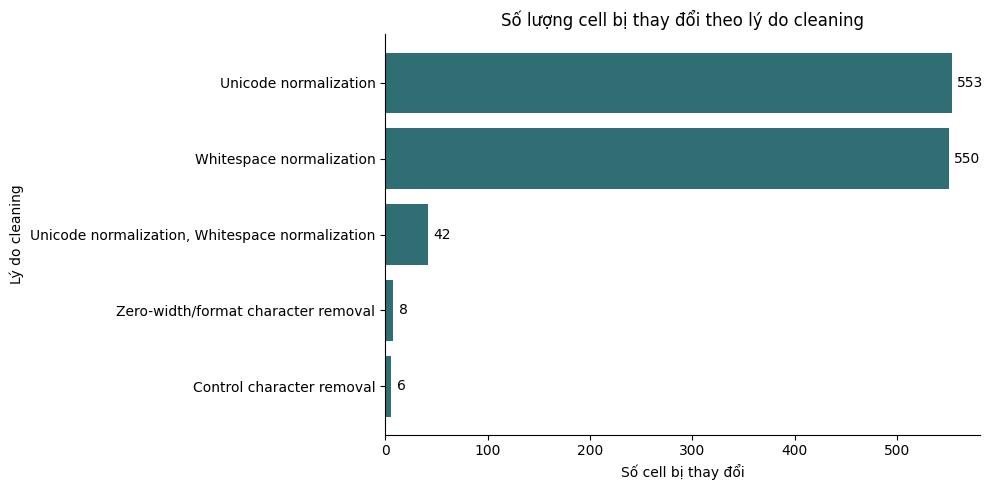

In [11]:
# Vẽ biểu đồ số lượng cell bị thay đổi theo lý do cleaning.
# Không lưu thêm file ảnh để folder report chỉ còn một file CSV audit.

import matplotlib.pyplot as plt

reason_counts = (
    all_cleaning_changes["reason"]
    .value_counts()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(reason_counts.index, reason_counts.values, color="#2F6F73")

ax.set_title("Số lượng cell bị thay đổi theo lý do cleaning")
ax.set_xlabel("Số cell bị thay đổi")
ax.set_ylabel("Lý do cleaning")
ax.bar_label(bars, padding=4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


## 5. Sanity checks

Các kiểm tra dưới đây đảm bảo common cleaning không vô tình tạo text rỗng, không để sót HTML tag trong các cột cleaned, và không thay đổi nhãn.

In [12]:
# Sanity checks sau khi chạy cleaning.
# Common cleaning phải giữ lại text hợp lệ, không để sót HTML tag trong cột cleaned,
# và không làm mất nhãn của dataset.

for split, df in cleaned_splits.items():
    assert df["claim_clean"].str.len().gt(0).all(), f"Empty claim_clean in {split}"
    assert df["evidence_clean"].str.len().gt(0).all(), f"Empty evidence_clean in {split}"
    assert df["label_clean"].notna().all(), f"Missing label_clean in {split}"
    assert not df["claim_clean"].str.contains(HTML_TAG_PATTERN).any(), f"HTML tag remains in claim_clean {split}"
    assert not df["evidence_clean"].str.contains(HTML_TAG_PATTERN).any(), f"HTML tag remains in evidence_clean {split}"

label_distributions = {
    split: df["label_clean"].value_counts(dropna=False).sort_index()
    for split, df in cleaned_splits.items()
}
label_distributions

{'train': label_clean
 0    1751
 1    1658
 2    1653
 Name: count, dtype: int64,
 'dev': label_clean
 0    256
 1    244
 2    223
 Name: count, dtype: int64,
 'test': label_clean
 0    508
 1    468
 2    471
 Name: count, dtype: int64}

In [13]:
# Hàm tiền xử lý chung được áp dụng cho tất cả mô hình.
# Chỉ xử lý các vấn đề kỹ thuật của dữ liệu:
# - Không tokenize
# - Không lowercase
# - Không loại bỏ stopword
# 
# Các bước đặc thù sẽ được thực hiện riêng cho từng model
# (TF-IDF, FastText + BiLSTM, PhoBERT, LLM).

display_columns = ["Statement", "claim_clean", "Evidence", "evidence_clean", "labels", "label_clean"]
cleaned_splits["train"][display_columns].head(3)

,Statement,claim_clean,Evidence,evidence_clean,labels,label_clean
0,"Phó Thủ tướng Trần Hồng Hà thay mặt Chính phủ, Thủ tướng Chính phủ chúc mừng Đài Truyền hình Việt Nam, Đài truyền hình các tỉnh, thành phố trên cả nước, các đơn vị sản xuất tru...","Phó Thủ tướng Trần Hồng Hà thay mặt Chính phủ, Thủ tướng Chính phủ chúc mừng Đài Truyền hình Việt Nam, Đài truyền hình các tỉnh, thành phố trên cả nước, các đơn vị sản xuất tru...","Thay mặt Chính phủ, Thủ tướng Chính phủ, Phó Thủ tướng Trần Hồng Hà chúc mừng Đài Truyền hình Việt Nam, Đài truyền hình các tỉnh, thành phố trên cả nước, các đơn vị sản xuất tr...","Thay mặt Chính phủ, Thủ tướng Chính phủ, Phó Thủ tướng Trần Hồng Hà chúc mừng Đài Truyền hình Việt Nam, Đài truyền hình các tỉnh, thành phố trên cả nước, các đơn vị sản xuất tr...",0,0
1,"Hành vi của Tô Văn Hải là cho phép người khác đổ chất thải rắn ra môi trường vàchôn, lấp chất thải trái phép.","Hành vi của Tô Văn Hải là cho phép người khác đổ chất thải rắn ra môi trường vàchôn, lấp chất thải trái phép.","Tô Văn Hải đã có hành vi cho phép người khác đổ, thải chất thải rắn thông thường ra môi trường Giáo). Sau đó, Hải tiến hành chôn, lấp tổng khối lượng 642.070 kg chất thải mà kh...","Tô Văn Hải đã có hành vi cho phép người khác đổ, thải chất thải rắn thông thường ra môi trường Giáo). Sau đó, Hải tiến hành chôn, lấp tổng khối lượng 642.070 kg chất thải mà kh...",0,0
2,"SAWACO thông báo tạm ngưng cung cấp nước để thực hiện công tác bảo trì, bảo dưỡng định kỳ Nhà máy nước Tân Hiệp, thời gian thực hiện dự kiến từ 12 giờ ngày 25-3 (thứ bảy) đến 4...","SAWACO thông báo tạm ngưng cung cấp nước để thực hiện công tác bảo trì, bảo dưỡng định kỳ Nhà máy nước Tân Hiệp, thời gian thực hiện dự kiến từ 12 giờ ngày 25-3 (thứ bảy) đến 4...",SAWACO thông báo tạm ngưng cung cấp nước để thực hiện công tác nêu trên. Thời gian thực hiện dự kiến từ 22 giờ ngày 25-3 (thứ bảy) đến 4 giờ ngày 26-3 (chủ nhật).,SAWACO thông báo tạm ngưng cung cấp nước để thực hiện công tác nêu trên. Thời gian thực hiện dự kiến từ 22 giờ ngày 25-3 (thứ bảy) đến 4 giờ ngày 26-3 (chủ nhật).,1,1


## Output cho các pipeline tiếp theo

Các file output nằm ở:

- `data/processed/common_cleaned/vifactcheck_train_common_cleaned.csv`
- `data/processed/common_cleaned/vifactcheck_dev_common_cleaned.csv`
- `data/processed/common_cleaned/vifactcheck_test_common_cleaned.csv`

Các file cleaned giữ lại tên cột gốc của dataset:

- `Statement`: claim sau common cleaning.
- `Context`: context sau common cleaning.
- `Evidence`: evidence sau common cleaning.
- `labels`: nhãn gốc, không đổi tên thành `label_clean`.

Report audit nằm ở:

- `reports/common_cleaning/all_cleaning_changes.csv`
